X shape: (500, 400)
logits shape: (500,)
分类标签 y_clf shape: (500,)


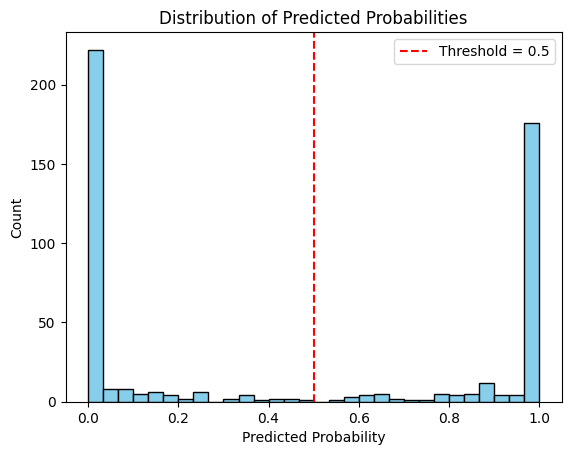

Epoch 0, Loss: 0.6966
Epoch 10, Loss: 0.5126
Epoch 20, Loss: 0.2312
Epoch 30, Loss: 0.0464
Epoch 40, Loss: 0.0076
Epoch 1/20, Loss: 0.7071, Val Loss: 0.6907
Epoch 2/20, Loss: 0.6852, Val Loss: 0.6932
Epoch 3/20, Loss: 0.6670, Val Loss: 0.6956
Epoch 4/20, Loss: 0.6510, Val Loss: 0.6980
Epoch 5/20, Loss: 0.6360, Val Loss: 0.6998
Epoch 6/20, Loss: 0.6209, Val Loss: 0.7009
Epoch 7/20, Loss: 0.6050, Val Loss: 0.7012
Epoch 8/20, Loss: 0.5879, Val Loss: 0.7010
Epoch 9/20, Loss: 0.5695, Val Loss: 0.6999
Epoch 10/20, Loss: 0.5497, Val Loss: 0.6982
Epoch 11/20, Loss: 0.5286, Val Loss: 0.6959
Epoch 12/20, Loss: 0.5061, Val Loss: 0.6932
Epoch 13/20, Loss: 0.4824, Val Loss: 0.6901
Epoch 14/20, Loss: 0.4575, Val Loss: 0.6866
Epoch 15/20, Loss: 0.4314, Val Loss: 0.6829
Epoch 16/20, Loss: 0.4044, Val Loss: 0.6792
Epoch 17/20, Loss: 0.3766, Val Loss: 0.6754
Epoch 18/20, Loss: 0.3482, Val Loss: 0.6718
Epoch 19/20, Loss: 0.3196, Val Loss: 0.6685
Epoch 20/20, Loss: 0.2909, Val Loss: 0.6656
Validation Accu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split


n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))

# 分类标签
X_logits = (
    X[:,50:80].sum(axis=1)*1.5 +    # 代谢模块（正相关）
    X[:,300:330].sum(axis=1)*(-2.0) # 信号通路模块（负相关）
)

# sigmoid 转概率
prob = 1 / (1 + np.exp(-X_logits))

# 二分类标签
y_clf = (prob > 0.5).astype(int)

# 打印结果检查
print("X shape:", X.shape)          # (500, 400)
print("logits shape:", X_logits.shape)  # (500,)
print("分类标签 y_clf shape:", y_clf.shape)  # (500,1)

# Step 4: 可视化标签分布
plt.hist(prob, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")
plt.legend()
plt.show()

# 数据准备
X_train, X_val, y_train, y_val = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)


# 定义 MLP 分类器
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),  # 输入层 → 隐藏层1
            nn.ReLU(),                  # 激活函数
            nn.Linear(128, 64),         # 隐藏层1 → 隐藏层2
            nn.ReLU(),                  # 激活函数
            nn.Linear(64, 1),           # 隐藏层2 → 输出层
            nn.Sigmoid()                # 输出概率 (0~1)
        )
    def forward(self, x):
        return self.net(x)
    



# 适合初学者的快速理解深度学习的基本流程：前向传播 → 损失 → 反向传播 → 更新
# 数据准备
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_clf, dtype=torch.float32).reshape(-1, 1)  # 转换为列向量

# 模型、损失函数、优化器
model = MLPClassifier(input_dim=400)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练循环
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# 初始化模型、损失函数和优化器
model = MLPClassifier(input_dim=n_gene)
criterion = nn.BCELoss()  # 二分类交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练模型
n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # 验证模型
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
    
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 评估模型,适合初学者理解模型性能的基本指标：准确率、精确率、召回率和F1分数
model.eval()
with torch.no_grad():
    val_outputs = model(X_val)
    predicted = (val_outputs > 0.5).float()  # 二分类阈值
    accuracy = accuracy_score(y_val, predicted)
    precision = precision_score(y_val, predicted)
    recall = recall_score(y_val, predicted)
    f1 = f1_score(y_val, predicted)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision: {precision:.4f}")
print(f"Validation Recall: {recall:.4f}")
print(f"Validation F1 Score: {f1:.4f}")


# 适合跟踪每个 epoch 的指标，方便调参和分析模型收敛情况。
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        
        # 将概率转为标签 (0/1)
        val_pred = (val_outputs > 0.5).int()
        
        # 计算性能指标
        acc = accuracy_score(y_val.numpy(), val_pred.numpy())
        precision = precision_score(y_val.numpy(), val_pred.numpy())
        recall = recall_score(y_val.numpy(), val_pred.numpy())
        f1 = f1_score(y_val.numpy(), val_pred.numpy())
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
          f"Acc: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")



In [2]:
theta = X.dot(X.T) / n_gene
y_pred = theta.dot(y_clf)
y_pred = (y_pred > 0.5).astype(int)
accuracy = (y_pred == y_clf).mean() 
print(f"基于相关性矩阵的分类准确率: {accuracy:.4f}")

基于相关性矩阵的分类准确率: 0.8340


Epoch 1/20, Train Loss: 0.6896, Val Loss: 0.7003, Acc: 0.4700, F1: 0.6395
Epoch 2/20, Train Loss: 0.6716, Val Loss: 0.6979, Acc: 0.4700, F1: 0.6395
Epoch 3/20, Train Loss: 0.6545, Val Loss: 0.6953, Acc: 0.4800, F1: 0.6438
Epoch 4/20, Train Loss: 0.6373, Val Loss: 0.6926, Acc: 0.4800, F1: 0.6438
Epoch 5/20, Train Loss: 0.6193, Val Loss: 0.6897, Acc: 0.4600, F1: 0.6250
Epoch 6/20, Train Loss: 0.6002, Val Loss: 0.6865, Acc: 0.4700, F1: 0.6294
Epoch 7/20, Train Loss: 0.5796, Val Loss: 0.6829, Acc: 0.4800, F1: 0.6286
Epoch 8/20, Train Loss: 0.5576, Val Loss: 0.6789, Acc: 0.5300, F1: 0.6466
Epoch 9/20, Train Loss: 0.5340, Val Loss: 0.6744, Acc: 0.5400, F1: 0.6406
Epoch 10/20, Train Loss: 0.5088, Val Loss: 0.6695, Acc: 0.5300, F1: 0.6240
Epoch 11/20, Train Loss: 0.4820, Val Loss: 0.6642, Acc: 0.5300, F1: 0.6116
Epoch 12/20, Train Loss: 0.4539, Val Loss: 0.6586, Acc: 0.5400, F1: 0.6102
Epoch 13/20, Train Loss: 0.4245, Val Loss: 0.6530, Acc: 0.5600, F1: 0.6140
Epoch 14/20, Train Loss: 0.3942, V

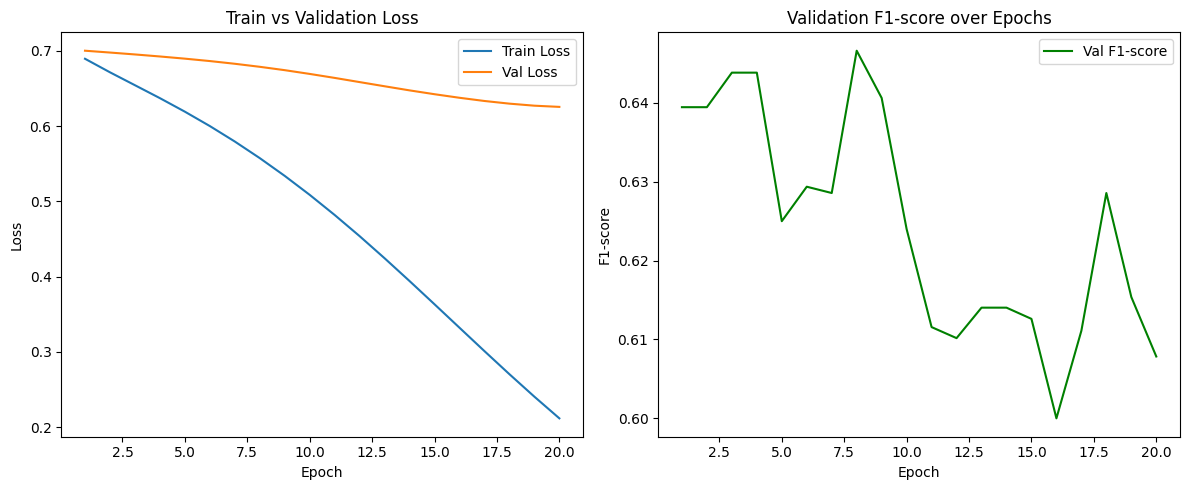

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# 数据生成
n_gene = 400
n_samples = 500
X = np.random.normal(0,1,(n_samples,n_gene))
X_logits = X[:,50:80].sum(axis=1)*1.5 + X[:,300:330].sum(axis=1)*(-2.0)
prob = 1 / (1 + np.exp(-X_logits))
y_clf = (prob > 0.5).astype(int)

# 划分训练/验证集
X_train, X_val, y_train, y_val = train_test_split(X, y_clf, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# 定义 MLP 分类器
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# 初始化模型、损失函数和优化器
model = MLPClassifier(input_dim=n_gene)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 保存指标
train_losses, val_losses, val_accs, val_f1s = [], [], [], []

n_epochs = 20
for epoch in range(n_epochs):
    # 训练
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # 验证
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())
        
        val_pred = (val_outputs > 0.5).int()
        acc = accuracy_score(y_val.numpy(), val_pred.numpy())
        f1 = f1_score(y_val.numpy(), val_pred.numpy())
        val_accs.append(acc)
        val_f1s.append(f1)
    
    print(f"Epoch {epoch+1}/{n_epochs}, "
          f"Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, "
          f"Acc: {acc:.4f}, F1: {f1:.4f}")

# 绘制曲线
plt.figure(figsize=(12,5))

# 损失曲线
plt.subplot(1,2,1)
plt.plot(range(1,n_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1,n_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

# F1-score 曲线
plt.subplot(1,2,2)
plt.plot(range(1,n_epochs+1), val_f1s, label="Val F1-score", color="green")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Validation F1-score over Epochs")
plt.legend()

plt.tight_layout()
plt.show()
